## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier

C:\Users\LEGION\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## EDA

In [3]:
test_ids = test['id']
train = train.drop(columns='id')
test = test.drop(columns='id')

In [4]:
train.describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  str    
dtypes: float64(8), str(3)
memory usage: 58.5 MB


In [14]:
train.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [5]:
train.shape

(577347, 11)

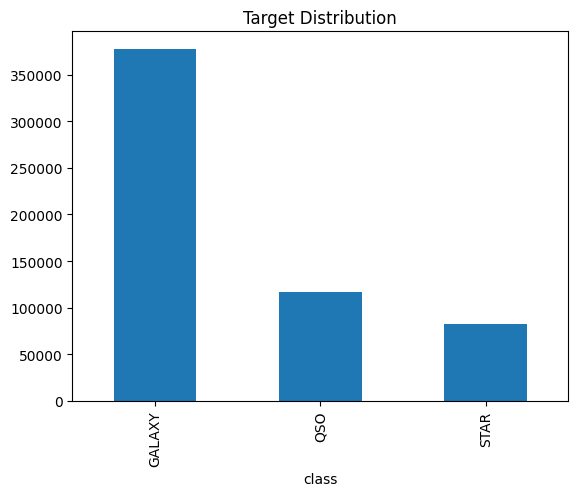

In [6]:
train['class'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.show()

In [4]:
target_dict = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
train['class'] = train['class'].map(target_dict)

In [9]:
train.groupby(['spectral_type','class']).count()

alpha   delta       u       g       r       i       z  \
spectral_type class                                                           
A/F           0       24240   24240   24240   24240   24240   24240   24240   
              1       61514   61514   61514   61514   61514   61514   61514   
              2       36368   36368   36368   36368   36368   36368   36368   
G/K           0       61627   61627   61627   61627   61627   61627   61627   
              1       20921   20921   20921   20921   20921   20921   20921   
              2       25998   25998   25998   25998   25998   25998   25998   
M             0      288023  288023  288023  288023  288023  288023  288023   
              1        3889    3889    3889    3889    3889    3889    3889   
              2       11411   11411   11411   11411   11411   11411   11411   
O/B           0        3590    3590    3590    3590    3590    3590    3590   
              1       30819   30819   30819   30819   30819   30819   30819   
              2        8947    8947    8947    8947    8947    8947    8947   

                     redshift  galaxy_population  
spectral_type class                               
A/F           0         24240              24240  
              1         61514              61514  
              2         36368              36368  
G/K           0         61627              61627  
              1         20921              20921  
              2         25998              25998  
M             0        288023             288023  
              1          3889               3889  
              2         11411              11411  
O/B           0          3590               3590  
              1         30819              30819  
              2          8947               8947

In [42]:
train.groupby('spectral_type')['c']

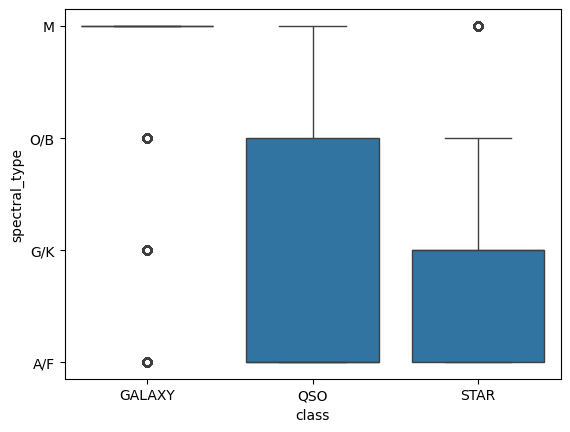

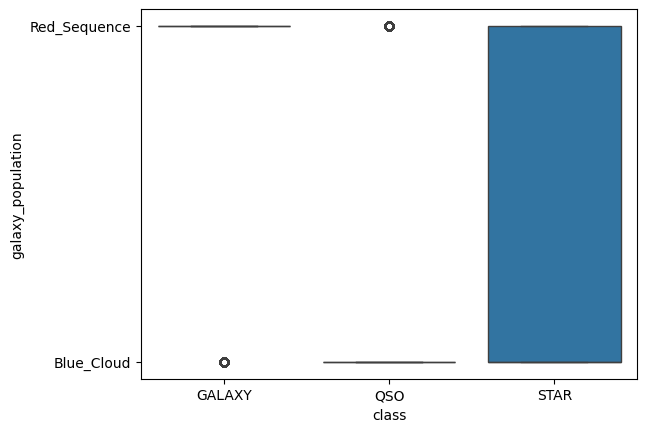

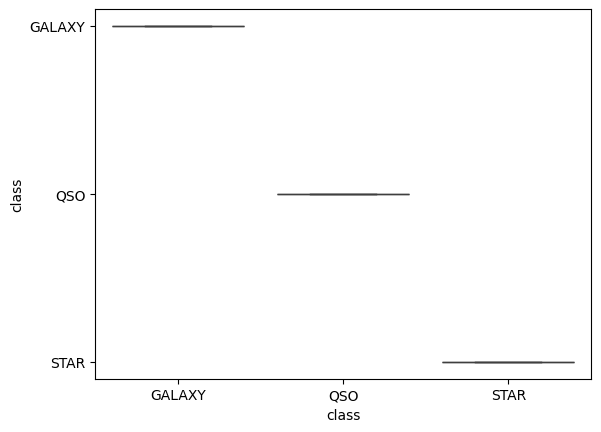

In [37]:
for i in train.select_dtypes('str').columns:
    sns.boxplot(x='class', y=i, data=train)
    plt.show()

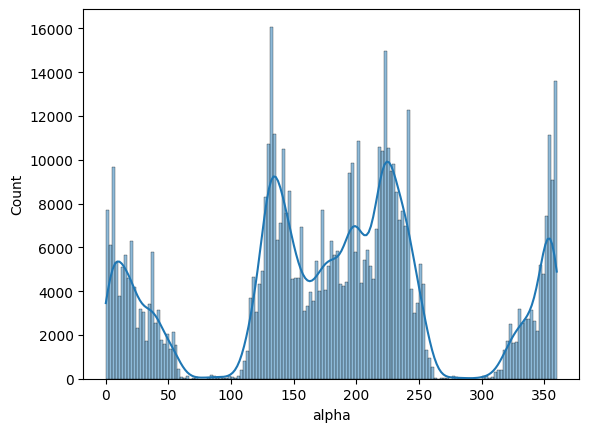

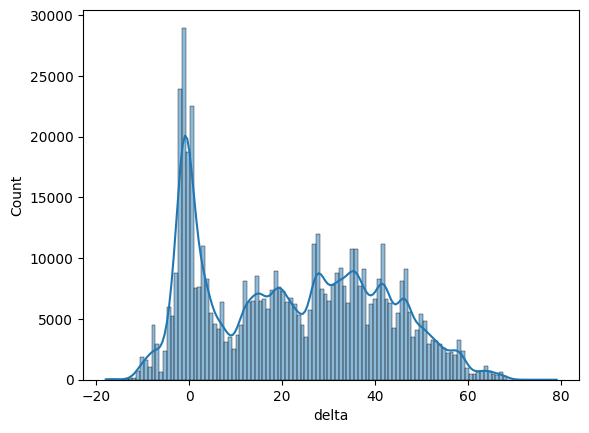

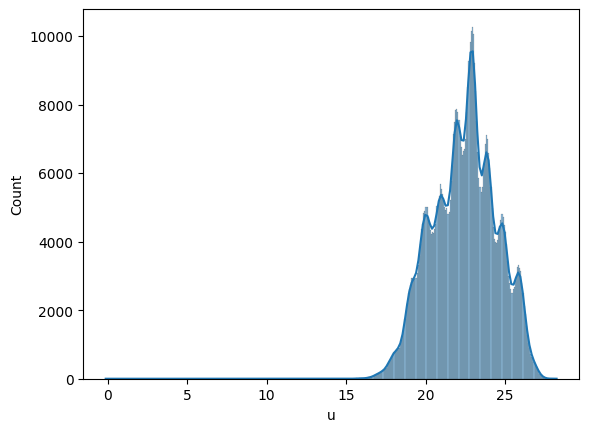

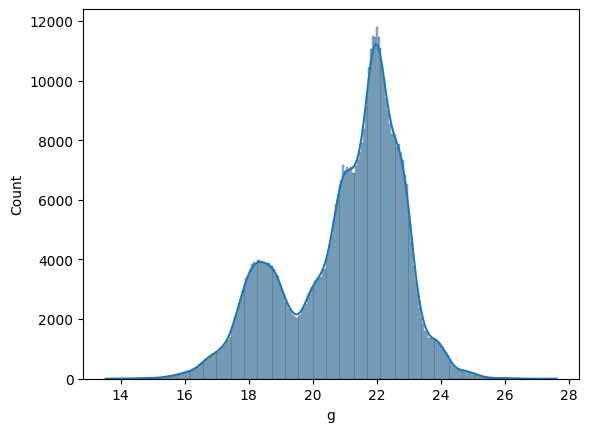

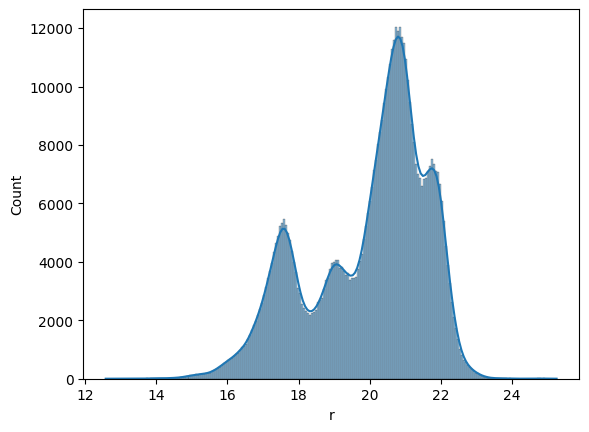

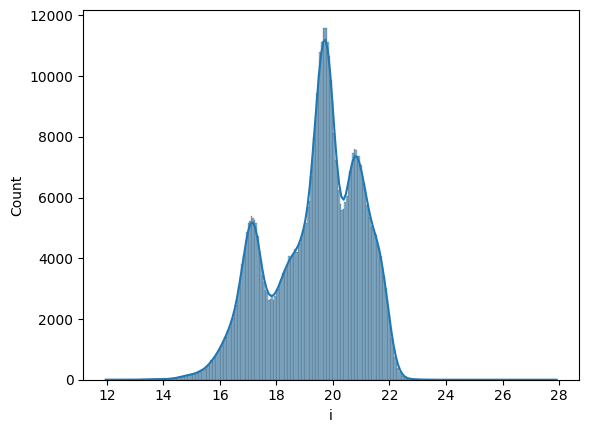

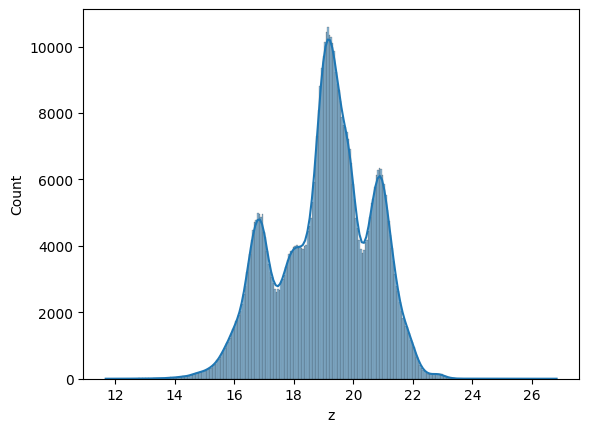

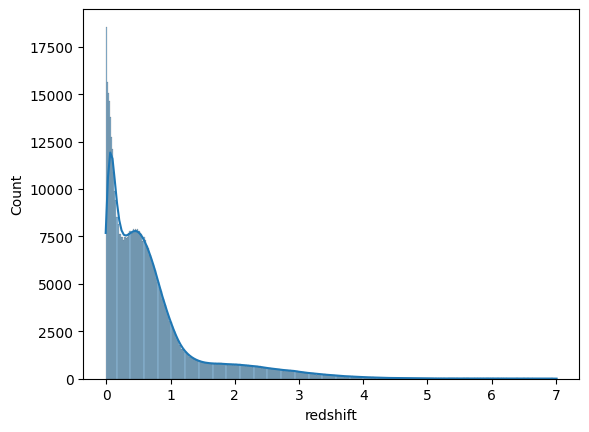

In [10]:
for i in train.select_dtypes('number').columns:
    sns.histplot(train[i], kde=True)
    plt.show()

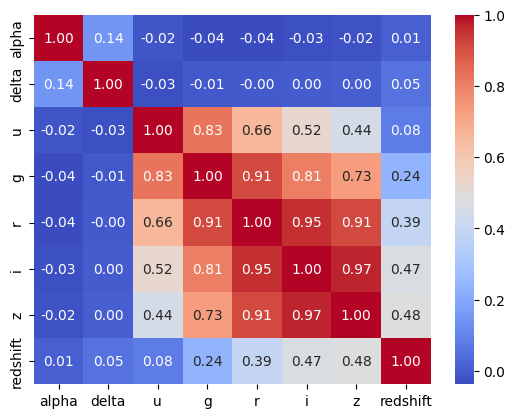

In [12]:
sns.heatmap(train.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

## Encoding

In [5]:
train = pd.get_dummies(train, columns=['spectral_type'], drop_first=True)
test = pd.get_dummies(test, columns=['spectral_type'], drop_first=True)
galaxy_dict = {'Red_Sequence': 0, 'Blue_Cloud': 1}
train['galaxy_population'] = train['galaxy_population'].map(galaxy_dict)
test['galaxy_population'] = test['galaxy_population'].map(galaxy_dict)

## Feature Engineering

In [236]:
print(train['redshift'].min())
print(train['redshift'].describe())

-0.0099703582110835
count    577347.000000
mean          0.723135
std           0.810070
min          -0.009970
25%           0.181052
50%           0.497525
75%           0.881390
max           7.010780
Name: redshift, dtype: float64


In [6]:
train['redshift_log'] = np.log1p(train['redshift'])
test['redshift_log'] = np.log1p(test['redshift'])

In [238]:
print(train[['u', 'g', 'r', 'i', 'z', 'redshift']].describe())

                   u              g              r              i  \
count  577347.000000  577347.000000  577347.000000  577347.000000   
mean       22.441926      21.007273      19.962811      19.378911   
std         2.018135       1.795426       1.648964       1.580059   
min        -0.139225      13.535483      12.579407      11.962781   
25%        20.977090      19.865005      18.820671      18.306820   
50%        22.570222      21.467820      20.431153      19.631642   
75%        23.869103      22.292715      21.164096      20.608191   
max        28.253263      27.620208      25.254499      27.910853   

                   z       redshift  
count  577347.000000  577347.000000  
mean       19.041136       0.723135  
std         1.584365       0.810070  
min        11.682803      -0.009970  
25%        17.973192       0.181052  
50%        19.188598       0.497525  
75%        20.162111       0.881390  
max        26.826867       7.010780  


In [7]:
train['u_g'] = train['u'] - train['g']
train['g_r'] = train['g'] - train['r']
train['r_i'] = train['r'] - train['i']
train['i_z'] = train['i'] - train['z']

In [8]:
test['u_g'] = test['u'] - test['g']
test['g_r'] = test['g'] - test['r']
test['r_i'] = test['r'] - test['i']
test['i_z'] = test['i'] - test['z']

In [9]:
for i in ['u_g', 'g_r', 'r_i', 'i_z']:
    train[i] = train[i].clip(lower=-5)
    test[i] = test[i].clip(lower=-5)

In [10]:
float64cols = train.select_dtypes('float64').columns
for i in float64cols:
    train[i] = train[i].astype('float32')
    test[i] = test[i].astype('float32')

## Cross Validation

In [11]:
X = train.drop(columns='class')
y = train['class']

In [14]:
best_params_lgbm = {'num_leaves': 140, 'learning_rate': 0.020344567389285292, 'n_estimators': 670, 'min_child_samples': 268, 'subsample': 0.9920460113544618, 'colsample_bytree': 0.6102025421046767}

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LGBMClassifier(**best_params_lgbm, n_jobs=-1, class_weight='balanced' )

scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy')
print(f'CV: {scores.mean(): .4f} | Std {scores.std(): .4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

including the divide and subtracting functions:
CV:  0.9636 | Std  0.0005

excluding the divide function and only subtracting function:
CV:  0.9637 | Std  0.0005

excluding all functions except redshift:
CV:  0.9561 | Std  0.0006

excluding every function(no feature engineering) :
CV:  0.9561 | Std  0.0005

## Hyperparameter Tuning

In [13]:
print(study.best_params)
print(study.best_value)
print(f"Trials completed: {len(study.trials)}")

{'num_leaves': 240, 'learning_rate': 0.00613683068989773, 'n_estimators': 1898, 'min_child_samples': 290, 'subsample': 0.9101470855029066, 'colsample_bytree': 0.7508805280096817, 'reg_alpha': 1.209557888421072, 'reg_lambda': 1.9188326902186619}
0.9652978835034884
Trials completed: 58


In [ ]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 30, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 3000),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 600),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='balanced_accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.INFO)
study.optimize(objective, n_trials=300, timeout=28800)
print(study.best_params)
print(study.best_value)

In [15]:
def objective(trial):

    params = {
        'num_leaves': trial.suggest_int('num_leaves', 50, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    

    model = LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy')

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(study.best_params)
print(study.best_value)

[I 2026-06-13 18:58:05,220] A new study created in memory with name: no-name-8e3b76b3-0fef-4935-80ca-15a6e2f760dd


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

[I 2026-06-13 19:02:37,711] Trial 0 finished with value: 0.9565195331540323 and parameters: {'num_leaves': 384, 'learning_rate': 0.18237347506849355, 'n_estimators': 926, 'min_child_samples': 209, 'subsample': 0.8015637091440528, 'colsample_bytree': 0.9708225554512271}. Best is trial 0 with value: 0.9565195331540323.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

[I 2026-06-13 19:07:17,128] Trial 1 finished with value: 0.9567108092210294 and parameters: {'num_leaves': 170, 'learning_rate': 0.16769764232162893, 'n_estimators': 1806, 'min_child_samples': 223, 'subsample': 0.7457759813017427, 'colsample_bytree': 0.8278741879696683}. Best is trial 1 with value: 0.9567108092210294.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

[I 2026-06-13 20:33:07,132] Trial 48 finished with value: 0.96393932592103 and parameters: {'num_leaves': 75, 'learning_rate': 0.05537330491754934, 'n_estimators': 903, 'min_child_samples': 217, 'subsample': 0.9297911960206622, 'colsample_bytree': 0.6141377298391939}. Best is trial 26 with value: 0.9648230497606082.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 384898, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

[I 2026-06-13 20:34:12,510] Trial 49 finished with value: 0.9646552631656836 and parameters: {'num_leaves': 108, 'learning_rate': 0.028591946123835553, 'n_estimators': 746, 'min_child_samples': 314, 'subsample': 0.9767853118865342, 'colsample_bytree': 0.5731527794583712}. Best is trial 26 with value: 0.9648230497606082.


{'num_leaves': 140, 'learning_rate': 0.020344567389285292, 'n_estimators': 670, 'min_child_samples': 268, 'subsample': 0.9920460113544618, 'colsample_bytree': 0.6102025421046767}
0.9648230497606082


Best Parameters: {'num_leaves': 140, 'learning_rate': 0.020344567389285292, 'n_estimators': 670, 'min_child_samples': 268, 'subsample': 0.9920460113544618, 'colsample_bytree': 0.6102025421046767}

Best Score: 0.9648230497606082

In [14]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 500),
        'verbose': 0,
        'thread_count': -1,
        'random_seed': 42
    }
    model = CatBoostClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, 
                             scoring='balanced_accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.INFO)
study.optimize(objective, n_trials=25)
print(study.best_params)
print(study.best_value)

[I 2026-06-13 18:57:32,446] A new study created in memory with name: no-name-1f5cf240-db64-4355-87ae-99437a63158e
[W 2026-06-13 18:57:46,288] Trial 0 failed with parameters: {'iterations': 1606, 'learning_rate': 0.1262763732967115, 'depth': 7, 'l2_leaf_reg': 1.3335643495980927, 'min_data_in_leaf': 159} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "C:\Users\LEGION\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\LEGION\AppData\Local\Temp\ipykernel_972\3486134825.py", line 14, in objective
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='balanced_accuracy')
  File "C:\Users\LEGION\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\LEGION\AppData\Local\Python\pythoncore-3.14-64

KeyboardInterrupt: 

In [37]:
def objective(trial):

    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy')

    return scores.mean()

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.INFO)
study.optimize(objective, n_trials=50)

print(study.best_params)
print(study.best_value)

[I 2026-06-14 17:11:15,807] A new study created in memory with name: no-name-17511111-fd57-4ceb-8c9b-98f795c468d1
[I 2026-06-14 17:11:41,762] Trial 0 finished with value: 0.9531871853933175 and parameters: {'max_depth': 6, 'learning_rate': 0.2197319845012872, 'n_estimators': 363, 'min_child_weight': 6, 'subsample': 0.5452037187719753, 'colsample_bytree': 0.5744861105002829}. Best is trial 0 with value: 0.9531871853933175.
[I 2026-06-14 17:13:30,288] Trial 1 finished with value: 0.9528419541861232 and parameters: {'max_depth': 3, 'learning_rate': 0.15809867647972087, 'n_estimators': 1787, 'min_child_weight': 9, 'subsample': 0.7431599518023704, 'colsample_bytree': 0.736245281872132}. Best is trial 0 with value: 0.9531871853933175.
[I 2026-06-14 17:15:21,421] Trial 2 finished with value: 0.9539034485021954 and parameters: {'max_depth': 7, 'learning_rate': 0.21365506545289634, 'n_estimators': 1007, 'min_child_weight': 1, 'subsample': 0.8662121922330729, 'colsample_bytree': 0.79212104709787

{'max_depth': 9, 'learning_rate': 0.04492990661994803, 'n_estimators': 1452, 'min_child_weight': 4, 'subsample': 0.8692057613916987, 'colsample_bytree': 0.8686388248879433}
0.9551519925926303


Best Parameters: {'max_depth': 9, 'learning_rate': 0.04492990661994803, 'n_estimators': 1452, 'min_child_weight': 4, 'subsample': 0.8692057613916987, 'colsample_bytree': 0.8686388248879433}

Best Score: 0.9551519925926303

In [15]:
best_params_lgbm = {'num_leaves': 140, 'learning_rate': 0.020344567389285292, 'n_estimators': 670, 'min_child_samples': 268, 'subsample': 0.9920460113544618, 'colsample_bytree': 0.6102025421046767}
best_params_cat = {'iterations': 1718, 'learning_rate': 0.19842040791509527, 'depth': 6, 'l2_leaf_reg': 4.364947393776207, 'min_data_in_leaf': 177}

## Final Fitting and Submitting

In [16]:
final_model = LGBMClassifier(**best_params_lgbm, n_jobs=-1, class_weight='balanced' )

In [17]:
final_model.fit(X, y)
predictions = final_model.predict(test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 577347, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

In [19]:
target_dict_inverse = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

In [20]:
final_predictions = [target_dict_inverse[x] for x in predictions]

In [21]:
submission_data = {'id': test_ids, 'class': final_predictions}
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv('lgmb_model_tuned_5.csv', index=False)

# CAT and LIGHT ENSEMBLE

## Ensemble Fitting and Submitting

In [17]:
lgbm_oof = np.zeros((len(X), 3))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(X, y):
    lgbm = LGBMClassifier(**best_params_lgbm, 
                          class_weight='balanced', n_jobs=-1)
    lgbm.fit(X.iloc[train_idx], y.iloc[train_idx])
    lgbm_oof[val_idx] = lgbm.predict_proba(X.iloc[val_idx])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 461877, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

In [18]:
cat_oof = np.zeros((len(X), 3))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(X, y):
    cat = CatBoostClassifier(**best_params_cat, thread_count=-1)
    cat.fit(X.iloc[train_idx], y.iloc[train_idx])
    cat_oof[val_idx] = cat.predict_proba(X.iloc[val_idx])

0:	learn: 0.8128951	total: 220ms	remaining: 6m 17s
1:	learn: 0.6502746	total: 272ms	remaining: 3m 53s
2:	learn: 0.5399263	total: 315ms	remaining: 2m 59s
3:	learn: 0.4590568	total: 354ms	remaining: 2m 31s
4:	learn: 0.3985884	total: 392ms	remaining: 2m 14s
5:	learn: 0.3513223	total: 433ms	remaining: 2m 3s
6:	learn: 0.3147818	total: 474ms	remaining: 1m 55s
7:	learn: 0.2853293	total: 517ms	remaining: 1m 50s
8:	learn: 0.2623469	total: 553ms	remaining: 1m 45s
9:	learn: 0.2441126	total: 591ms	remaining: 1m 40s
10:	learn: 0.2268728	total: 633ms	remaining: 1m 38s
11:	learn: 0.2140173	total: 670ms	remaining: 1m 35s
12:	learn: 0.2028902	total: 708ms	remaining: 1m 32s
13:	learn: 0.1926623	total: 753ms	remaining: 1m 31s
14:	learn: 0.1844907	total: 797ms	remaining: 1m 30s
15:	learn: 0.1773955	total: 844ms	remaining: 1m 29s
16:	learn: 0.1715563	total: 891ms	remaining: 1m 29s
17:	learn: 0.1666750	total: 933ms	remaining: 1m 28s
18:	learn: 0.1622320	total: 981ms	remaining: 1m 27s
19:	learn: 0.1576700	to

In [19]:
best_weight = 0
best_score = 0

for lgbm_w in np.arange(0.1, 1.0, 0.05):
    cat_w = 1 - lgbm_w
    ensemble = lgbm_oof * lgbm_w + cat_oof * cat_w
    score = balanced_accuracy_score(y, np.argmax(ensemble, axis=1))
    if score > best_score:
        best_score = score
        best_weight = lgbm_w

print(f"Best LGBM weight: {best_weight:.2f}")
print(f"Best CV Score: {best_score:.4f}")

Best LGBM weight: 0.95
Best CV Score: 0.9650


In [20]:
cat_model = CatBoostClassifier(**best_params_cat, thread_count=-1)
lgbm_model = LGBMClassifier(**best_params_lgbm, class_weight='balanced', n_jobs=-1)

In [22]:
cat_preds = cat_model.predict_proba(test)
lgbm_preds = lgbm_model.predict_proba(test)
final_preds = lgbm_preds*0.95 + cat_preds*0.05

In [23]:
final_preds = np.argmax(final_preds, axis=1)
target_dict_inverse = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

In [26]:
final_preds_mapped = [target_dict_inverse[x] for x in final_preds]
submission_data = {'id': test_ids, 'class': final_preds_mapped}
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv('lgmb_cat_ensemble_4.csv', index=False)

# LIGHT and XGBOOST ENSEMBLE

In [38]:
best_params_xgb = {'max_depth': 9, 'learning_rate': 0.04492990661994803, 'n_estimators': 1452, 'min_child_weight': 4, 'subsample': 0.8692057613916987, 'colsample_bytree': 0.8686388248879433}

In [ ]:
xgb_oof = np.zeros((len(X), 3))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    print(f"Fold {fold+1}/5")
    xgb = XGBClassifier(**best_params_xgb, n_jobs=1, random_state=42)
    xgb.fit(X.iloc[train_idx], y.iloc[train_idx])
    xgb_oof[val_idx] = xgb.predict_proba(X.iloc[val_idx])

Fold 1/5


In [ ]:
lgbm_oof = np.zeros((len(X), 3))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(X, y):
    lgbm = LGBMClassifier(**best_params_lgbm, 
                          class_weight='balanced', n_jobs=-1)
    lgbm.fit(X.iloc[train_idx], y.iloc[train_idx])
    lgbm_oof[val_idx] = lgbm.predict_proba(X.iloc[val_idx])

In [ ]:
best_weight = 0
best_score = 0

for lgbm_w in np.arange(0.1, 1.0, 0.05):
    xgb_w = 1 - lgbm_w
    ensemble = lgbm_oof * lgbm_w + xgb_oof * xgb_w
    score = balanced_accuracy_score(y, np.argmax(ensemble, axis=1))
    if score > best_score:
        best_score = score
        best_weight = lgbm_w

print(f"Best LGBM weight: {best_weight:.2f}")
print(f"Best CV Score: {best_score:.4f}")

In [51]:
xgb_model = XGBClassifier(**best_params_xgb, n_jobs=1)
lgbm_model = LGBMClassifier(**best_params_lgbm, class_weight='balanced', n_jobs=-1)

In [52]:
xgb_model.fit(X, y)
lgbm_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3323
[LightGBM] [Info] Number of data points in the train set: 577347, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


,boosting_type,'gbdt'
,num_leaves,140
,max_depth,-1
,learning_rate,0.020344567389285292
,n_estimators,670
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,268


In [53]:
xgb_preds = xgb_model.predict_proba(test)
lgbm_preds = lgbm_model.predict_proba(test)
final_preds = lgbm_preds*0.95 + xgb_preds*0.05

In [54]:
final_preds = np.argmax(final_preds, axis=1)
target_dict_inverse = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

In [55]:
final_preds_mapped = [target_dict_inverse[x] for x in final_preds]
submission_data = {'id': test_ids, 'class': final_preds_mapped}
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv('lgmb_xgb_ensemble_3.csv', index=False)

In [50]:
print(best_params_xgb)

{'max_depth': 9, 'learning_rate': 0.04492990661994803, 'n_estimators': 1452, 'min_child_weight': 4, 'subsample': 0.8692057613916987, 'colsample_bytree': 0.8686388248879433}
